In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

load_dotenv()  # 加载.env文件里的变量
print(os.getenv("DEEPSEEK_API_KEY"))  # 现在可以正常读取了

llm = ChatOpenAI(
    model="deepseek-chat",  # 使用的模型名称，目前官方推荐用 'deepseek-chat'
    api_key=os.getenv("DEEPSEEK_API_KEY"),  # 你的 DeepSeek API Key
    base_url="https://api.deepseek.com/v1",  # DeepSeek API 地址
    temperature=0,
)

sk-ff345e1cfac7491993b7e17cf9219fbf


In [3]:

import operator
from typing import Annotated, List, TypedDict

from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage,SystemMessage


class State(TypedDict):
    messages: Annotated[List[str],operator.add]
    
builder=StateGraph(State)

def chat_with_model(state):
    print(state)
    print("-------")
    messages=state['messages']
    response=llm.invoke(messages)
    return {'messages':[response]}

def convert_messages(state):
    prompt="""
    你是一位数据提取专家，负责从文本中检索关键信息，请为所提供的文本提取相关信息，并以json格式输出，概述锁提取的关键数据点。
    """
    
    print(state)
    print("----------------")
    messages=state['messages']
    messages=messages[-1]
    
    messages=[
        SystemMessage(content=prompt),
        HumanMessage(messages.content)
    ]
    
    response=llm.invoke(messages)
    return {'messages':[response]}

builder.add_node('chat_with_model',chat_with_model)
builder.add_node('convert_messages',convert_messages)

builder.add_edge(START,'chat_with_model')
builder.add_edge('chat_with_model','convert_messages')
builder.add_edge('convert_messages',END)

graph=builder.compile()

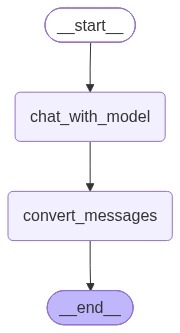

In [4]:
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [7]:
initial_state={'messages':['请详细的介绍一下你自己']}
result=graph.invoke(initial_state)
print(result['messages'][-1].content)

{'messages': ['请详细的介绍一下你自己']}
-------
{'messages': ['请详细的介绍一下你自己', AIMessage(content='你好呀！很高兴认识你！让我详细地介绍一下自己吧～\n\n## 我是谁\n我是**DeepSeek**，由**深度求索公司**创造的AI助手。我的使命就是帮助大家解答问题、提供信息、激发创意，成为你可靠的智能伙伴！\n\n## 我的核心能力\n- **纯文本对话**：我擅长文字交流，可以和你聊各种话题\n- **文件处理**：支持上传图像、txt、pdf、ppt、word、excel等文件，我能从中读取文字信息并帮你处理\n- **超长上下文**：拥有**1M上下文**能力，可以一次性处理《三体》三部曲那么大体量的内容！\n- **联网搜索**：虽然需要你在Web/App端手动开启，但开启后我就能获取最新信息\n- **多语言支持**：我会用你使用的语言回复你，中英文都没问题\n\n## 我的特点\n- ✅ **完全免费**：没错，我是免费的！目前没有任何收费计划\n- ✅ **知识更新**：我的知识截止到2025年5月\n- ✅ **App体验**：支持语音输入，还可以在官方应用商店下载App使用\n- ✅ **阅读链接**：我可以阅读你分享的链接内容\n\n## 我的限制\n- ❌ 不支持多模态识别（比如直接识别图片内容），但可以读取图片中的文字\n- ❌ 不能生成图片、视频等多媒体内容\n\n## 我的风格\n我喜欢用热情、细腻的方式和你交流，力求让每次对话都温暖而有价值。无论你是想探讨深奥的问题、寻求实用建议，还是单纯想聊聊天，我都非常乐意陪伴你！\n\n有什么我可以帮你的吗？尽管问我吧！😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 360, 'prompt_tokens': 8, 'total_tokens': 368, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_c